# RL Hyperparameter Tuning Analysis

Visualizes Stage 1 Bayesian Optimization / screening and Stage 2 robust validation. Switch `USE_HPC` in the configuration cell when final HPC outputs are ready.

In [1]:
from pathlib import Path
import json, math, warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass
sns.set_context("notebook")
pd.set_option("display.max_columns", 100)

In [2]:
USE_HPC = False
TUNING_ROOT = Path("rl_tuning_hpc") if USE_HPC else Path("rl_tuning_laptop")
STAGE1_DIR = TUNING_ROOT / "stage1"
STAGE2_DIR = TUNING_ROOT / "stage2"
TOP_N = 5
try:
    from rl_tuning_common import PARAMETER_NAMES as PROJECT_PARAMETER_NAMES
except Exception:
    PROJECT_PARAMETER_NAMES = ["alpha", "gamma", "epsilon_decay", "epsilon_min", "risk_t1", "risk_window"]
PARAMETER_NAMES = list(PROJECT_PARAMETER_NAMES)

## Helpers

In [3]:
def warn(message: str) -> None:
    warnings.warn(message, stacklevel=2)
    print(f"WARNING: {message}")

def read_csv_if_exists(path: Path, **kwargs) -> pd.DataFrame:
    if not path.exists():
        warn(f"Missing CSV: {path}")
        return pd.DataFrame()
    try:
        return pd.read_csv(path, **kwargs)
    except Exception as exc:
        warn(f"Could not read {path}: {exc}")
        return pd.DataFrame()

def read_json_if_exists(path: Path) -> dict:
    if not path.exists():
        warn(f"Missing JSON: {path}")
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as exc:
        warn(f"Could not read {path}: {exc}")
        return {}

def empty_plot_message(ax, message: str) -> None:
    ax.text(0.5, 0.5, message, ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()

def valid_rows(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    out = df.copy()
    if "error" in out.columns:
        out = out[out["error"].fillna("").astype(str).str.len() == 0].copy()
    return out

def coerce_numeric(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in columns:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out

def stage2_dir(root: Path) -> Path:
    return root / "stage2" if (root / "stage2").exists() else root

def candidate_dir_from_row(row, root: Path) -> Path | None:
    data = dict(row)
    raw = data.get("candidate_dir")
    if raw is not None and not pd.isna(raw):
        path = Path(str(raw))
        if path.exists(): return path
        fallback = stage2_dir(root) / path.name
        if fallback.exists(): return fallback
    rank, trial = data.get("candidate_rank"), data.get("source_trial_index")
    if rank is not None and trial is not None and not pd.isna(rank) and not pd.isna(trial):
        path = stage2_dir(root) / f"candidate_rank_{int(rank):02d}_trial_{int(trial):03d}"
        if path.exists(): return path
    return None

def load_stage1_trials(stage1_dir: Path = STAGE1_DIR) -> pd.DataFrame:
    df = read_csv_if_exists(stage1_dir / "stage1_trials.csv")
    if df.empty: return df
    nums = ["trial_index", "objective_mean", "objective_std", "best_objective_so_far", "total_reward_mean", "late_order_fraction_mean", "n_valid_replications", *PARAMETER_NAMES]
    df = coerce_numeric(df, nums).sort_values("trial_index").reset_index(drop=True)
    if "best_objective_so_far" not in df.columns or df["best_objective_so_far"].isna().all():
        if "objective_mean" in df.columns: df["best_objective_so_far"] = df["objective_mean"].cummin()
    return df

def load_stage2_candidates(root: Path = TUNING_ROOT) -> pd.DataFrame:
    for path in [stage2_dir(root) / "stage2_candidates.csv", root / "stage2_candidates.csv"]:
        if path.exists():
            df = read_csv_if_exists(path)
            if not df.empty:
                nums = ["candidate_rank", "source_trial_index", "objective_mean", "objective_std", "total_reward_mean", "stage1_objective_mean", "stage1_total_reward_mean", "late_order_fraction_mean", "n_valid_replications", *PARAMETER_NAMES]
                return coerce_numeric(df, nums)
    rows=[]
    for cdir in sorted(stage2_dir(root).glob("candidate_rank_*_trial_*")):
        summary = read_json_if_exists(cdir / "candidate_summary.json")
        if summary:
            row={"candidate_rank":summary.get("candidate_rank"), "source_trial_index":summary.get("source_trial_index"), "objective_mean":summary.get("objective_mean"), "objective_std":summary.get("objective_std"), "total_reward_mean":summary.get("total_reward_mean"), "late_order_fraction_mean":summary.get("late_order_fraction_mean"), "n_valid_replications":summary.get("n_valid_replications"), "candidate_dir":str(cdir)}
            row.update(summary.get("parameters", {})); rows.append(row)
    if rows:
        return coerce_numeric(pd.DataFrame(rows), ["candidate_rank", "source_trial_index", "objective_mean", "objective_std", "total_reward_mean", "late_order_fraction_mean", "n_valid_replications", *PARAMETER_NAMES])
    warn(f"No completed Stage-2 candidate summary data found under {root}")
    return pd.DataFrame()

def load_stage2_evaluations(candidates: pd.DataFrame, root: Path = TUNING_ROOT) -> pd.DataFrame:
    frames=[]; rows = candidates.to_dict('records') if not candidates.empty else [{"candidate_dir":str(p)} for p in sorted(stage2_dir(root).glob("candidate_rank_*_trial_*"))]
    for row in rows:
        cdir = candidate_dir_from_row(row, root)
        if cdir is None: continue
        ev = read_csv_if_exists(cdir / "evaluation.csv")
        if ev.empty: continue
        for key in ["candidate_rank", "source_trial_index"]:
            if key in row and key not in ev.columns: ev[key] = row[key]
        ev["candidate_dir"] = str(cdir)
        if "candidate_rank" in ev.columns and ev["candidate_rank"].notna().any(): ev["candidate_label"] = "Rank " + str(int(ev["candidate_rank"].dropna().iloc[0]))
        else: ev["candidate_label"] = cdir.name
        frames.append(ev)
    if not frames:
        warn("No Stage-2 evaluation.csv files found for candidate distributions.")
        return pd.DataFrame()
    return coerce_numeric(valid_rows(pd.concat(frames, ignore_index=True, sort=False)), ["total_reward", "late_order_fraction", "time_in_system_mean", "wip_mean", "n_orders_late", "candidate_rank", "replication"])

## Load Tuning Data

In [4]:
stage1_config = read_json_if_exists(STAGE1_DIR / "stage1_config.json")
stage2_config = read_json_if_exists(STAGE2_DIR / "stage2_config.json")
stage1_trials = load_stage1_trials(STAGE1_DIR)
stage2_candidates = load_stage2_candidates(TUNING_ROOT)
stage2_evaluations = load_stage2_evaluations(stage2_candidates, TUNING_ROOT)
display(pd.DataFrame([
    {"source":"stage1_trials", "path":STAGE1_DIR / "stage1_trials.csv", "rows":len(stage1_trials)},
    {"source":"stage2_candidates", "path":STAGE2_DIR / "stage2_candidates.csv", "rows":len(stage2_candidates)},
    {"source":"stage2_evaluations", "path":STAGE2_DIR / "candidate_*/evaluation.csv", "rows":len(stage2_evaluations)},
]))
if stage1_config: display(pd.DataFrame([stage1_config]).T.rename(columns={0:"stage1_config"}).head(20))
if stage2_config: display(pd.DataFrame([stage2_config]).T.rename(columns={0:"stage2_config"}).head(20))

,source,path,rows
0,stage1_trials,rl_tuning_laptop\stage1\stage1_trials.csv,5
1,stage2_candidates,rl_tuning_laptop\stage2\stage2_candidates.csv,1
2,stage2_evaluations,rl_tuning_laptop\stage2\candidate_*\evaluation...,10


,stage1_config
stage,stage1_bo
n_trials,5
training_episodes,50
eval_replications,1
bo_random_seed,24680
single_trial_script,C:\Workspace ZHAW\6. Semester\BA\BA-Simulation...
run_duration,1440
rate_multiplier,0.9
base_seed,12345
seed_step,1000


,stage2_config
stage,stage2_evaluate_top
stage1_dir,C:\Workspace ZHAW\6. Semester\BA\BA-Simulation...
n_top,1
training_episodes,1000
eval_replications,10
single_candidate_script,C:\Workspace ZHAW\6. Semester\BA\BA-Simulation...
run_duration,1440
rate_multiplier,0.9
base_seed,12345
seed_step,1000


## Stage 1: Best Objective So Far

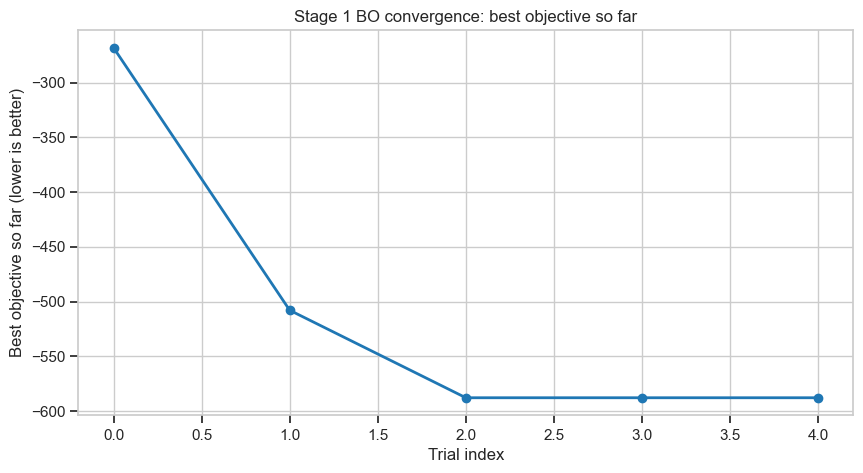

In [5]:
fig, ax = plt.subplots(figsize=(10,5))
if stage1_trials.empty or not {"trial_index", "best_objective_so_far"}.issubset(stage1_trials.columns): empty_plot_message(ax, "No Stage-1 convergence data available.")
else:
    ax.plot(stage1_trials["trial_index"], stage1_trials["best_objective_so_far"], marker="o", linewidth=2)
    ax.set_title("Stage 1 BO convergence: best objective so far"); ax.set_xlabel("Trial index"); ax.set_ylabel("Best objective so far (lower is better)")
plt.show()

## Stage 1: Objective per Trial

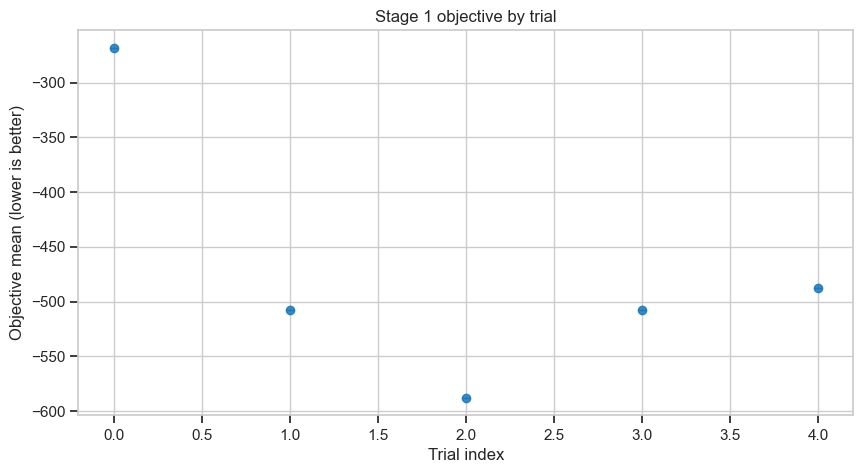

In [6]:
fig, ax = plt.subplots(figsize=(10,5))
if stage1_trials.empty or not {"trial_index", "objective_mean"}.issubset(stage1_trials.columns): empty_plot_message(ax, "No Stage-1 objective data available.")
else:
    yerr = None
    if {"objective_std", "n_valid_replications"}.issubset(stage1_trials.columns): yerr = stage1_trials["objective_std"] / np.sqrt(stage1_trials["n_valid_replications"].clip(lower=1))
    ax.errorbar(stage1_trials["trial_index"], stage1_trials["objective_mean"], yerr=yerr, fmt="o", capsize=3, alpha=0.85)
    ax.set_title("Stage 1 objective by trial"); ax.set_xlabel("Trial index"); ax.set_ylabel("Objective mean (lower is better)")
plt.show()

## Hyperparameters vs. Objective

C:\Users\fabia\AppData\Local\Temp\ipykernel_10352\2365449108.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.suptitle("Hyperparameters vs. Stage-1 objective", y=1.02); plt.tight_layout(); plt.show()


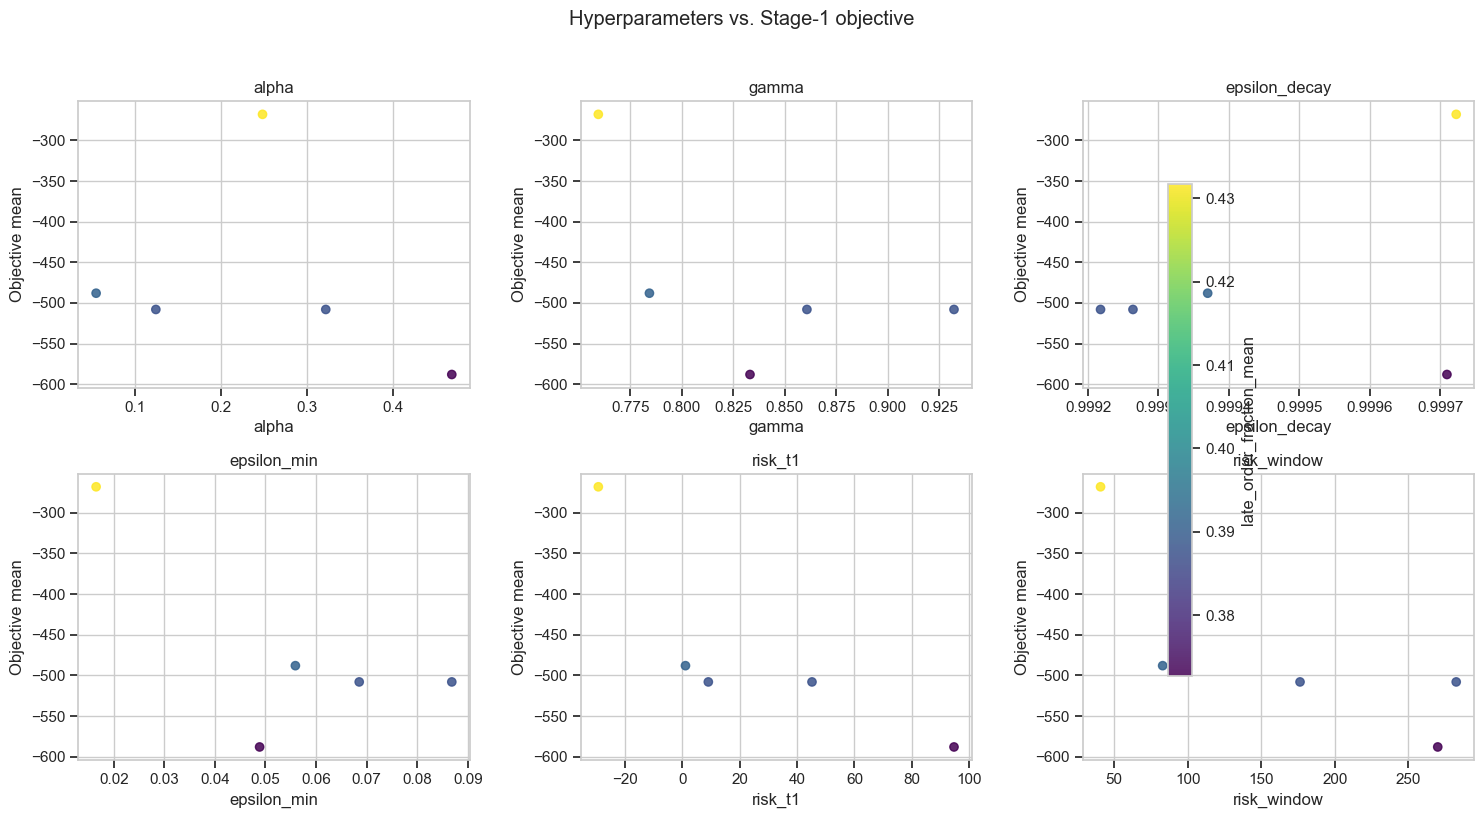

In [7]:
available_params = [p for p in PARAMETER_NAMES if p in stage1_trials.columns]
if not available_params or stage1_trials.empty or "objective_mean" not in stage1_trials.columns:
    fig, ax = plt.subplots(figsize=(8,4)); empty_plot_message(ax, "No hyperparameter/objective data available."); plt.show()
else:
    n_cols=3; n_rows=math.ceil(len(available_params)/n_cols); fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols,4*n_rows), squeeze=False)
    cvals = stage1_trials["late_order_fraction_mean"] if "late_order_fraction_mean" in stage1_trials.columns else None; sc=None
    for ax, p in zip(axes.ravel(), available_params):
        if cvals is not None and cvals.notna().any(): sc = ax.scatter(stage1_trials[p], stage1_trials["objective_mean"], c=cvals, cmap="viridis", alpha=0.85)
        else: ax.scatter(stage1_trials[p], stage1_trials["objective_mean"], alpha=0.85)
        ax.set_title(p); ax.set_xlabel(p); ax.set_ylabel("Objective mean")
    for ax in axes.ravel()[len(available_params):]: ax.set_axis_off()
    if sc is not None: fig.colorbar(sc, ax=axes.ravel().tolist(), label="late_order_fraction_mean", shrink=0.8)
    fig.suptitle("Hyperparameters vs. Stage-1 objective", y=1.02); plt.tight_layout(); plt.show()

## Top Parameter Configurations

,trial_index,alpha,gamma,epsilon_decay,epsilon_min,risk_t1,risk_window,objective_mean,total_reward_mean,late_order_fraction_mean,objective_std
2,2,0.468795,0.833084,0.999709,0.048835,94.690897,269.949233,-588.0,588.0,0.372694,0.0
1,1,0.322055,0.860726,0.999264,0.086826,45.185549,282.508719,-508.0,508.0,0.387454,0.0
3,3,0.124198,0.932154,0.999218,0.068527,9.047659,176.313810,-508.0,508.0,0.387454,0.0
4,4,0.054640,0.784241,0.999370,0.055908,1.081028,82.902268,-488.0,488.0,0.391144,0.0
0,0,0.248409,0.759426,0.999722,0.016515,-29.296952,40.674027,-268.0,268.0,0.431734,0.0


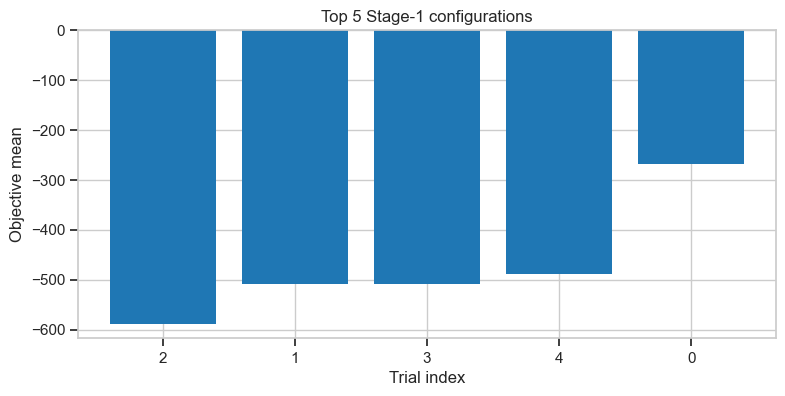

In [8]:
if stage1_trials.empty: print("No Stage-1 trials available.")
else:
    cols = ["trial_index", *available_params, "objective_mean", "total_reward_mean", "late_order_fraction_mean", "objective_std"]
    top_configs = stage1_trials.sort_values("objective_mean").head(min(TOP_N, len(stage1_trials)))[[c for c in cols if c in stage1_trials.columns]]
    display(top_configs)
    fig, ax = plt.subplots(figsize=(9,4))
    ax.bar(top_configs["trial_index"].astype(str), top_configs["objective_mean"], color="tab:blue")
    ax.set_title(f"Top {len(top_configs)} Stage-1 configurations"); ax.set_xlabel("Trial index"); ax.set_ylabel("Objective mean"); plt.show()

## Stage 1 vs. Stage 2

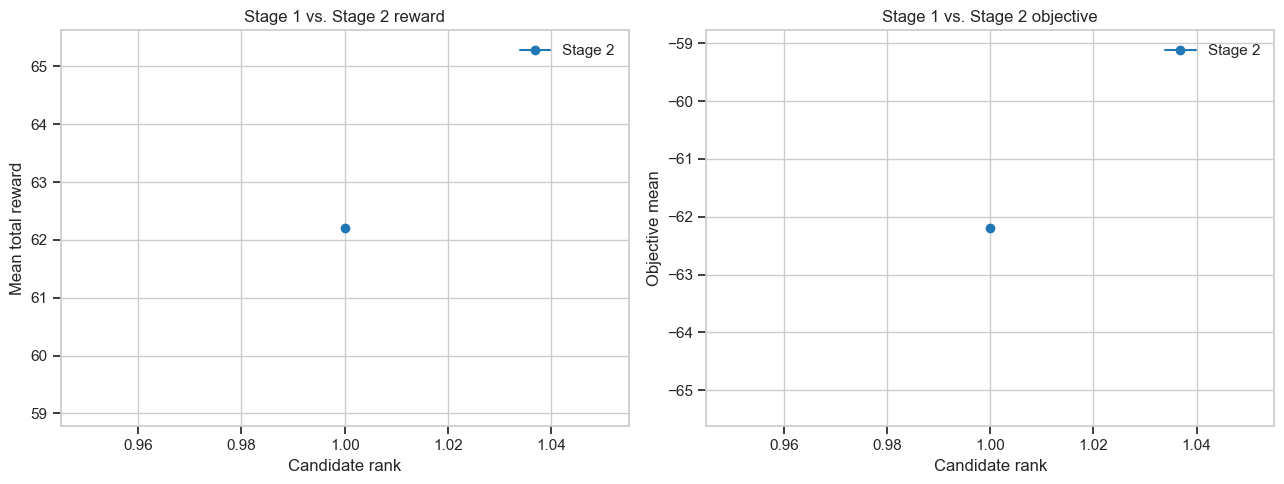

,candidate_rank,source_trial_index,alpha,gamma,epsilon_decay,epsilon_min,risk_t1,risk_window,stage1_objective_mean,stage1_total_reward_mean,objective_mean,objective_std,total_reward_mean,total_reward_std,late_order_fraction_mean,n_valid_replications,best_training_reward,best_training_episode,best_training_seed,best_evaluation_reward,best_evaluation_replication,best_evaluation_seed,q_table_size,candidate_dir,q_table_path
0,1,2,0.468795,0.833084,0.999709,0.048835,94.690897,269.949233,NaN,NaN,-62.2,201.316114,62.2,201.316114,0.472279,10,1009.0,518,730345,408.0,0,312345,23,C:\Workspace ZHAW\6. Semester\BA\BA-Simulation...,C:\Workspace ZHAW\6. Semester\BA\BA-Simulation...


In [9]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
if stage2_candidates.empty:
    for ax in axes: empty_plot_message(ax, "No Stage-2 candidate summary available.")
else:
    data = stage2_candidates.copy().sort_values("candidate_rank") if "candidate_rank" in stage2_candidates.columns else stage2_candidates.copy()
    x = data["candidate_rank"] if "candidate_rank" in data.columns else np.arange(1, len(data)+1)
    for ax, stage1_col, stage2_col, title, ylabel in [
        (axes[0], "stage1_total_reward_mean", "total_reward_mean", "Stage 1 vs. Stage 2 reward", "Mean total reward"),
        (axes[1], "stage1_objective_mean", "objective_mean", "Stage 1 vs. Stage 2 objective", "Objective mean")]:
        plotted=False
        if stage1_col in data.columns and data[stage1_col].notna().any(): ax.plot(x, data[stage1_col], marker="o", label="Stage 1"); plotted=True
        if stage2_col in data.columns and data[stage2_col].notna().any(): ax.plot(x, data[stage2_col], marker="o", label="Stage 2"); plotted=True
        if plotted: ax.set_title(title); ax.set_xlabel("Candidate rank"); ax.set_ylabel(ylabel); ax.legend()
        else: empty_plot_message(ax, f"No {ylabel.lower()} comparison available.")
plt.tight_layout(); plt.show(); display(stage2_candidates)

## Stage-2 Replication KPI Distributions

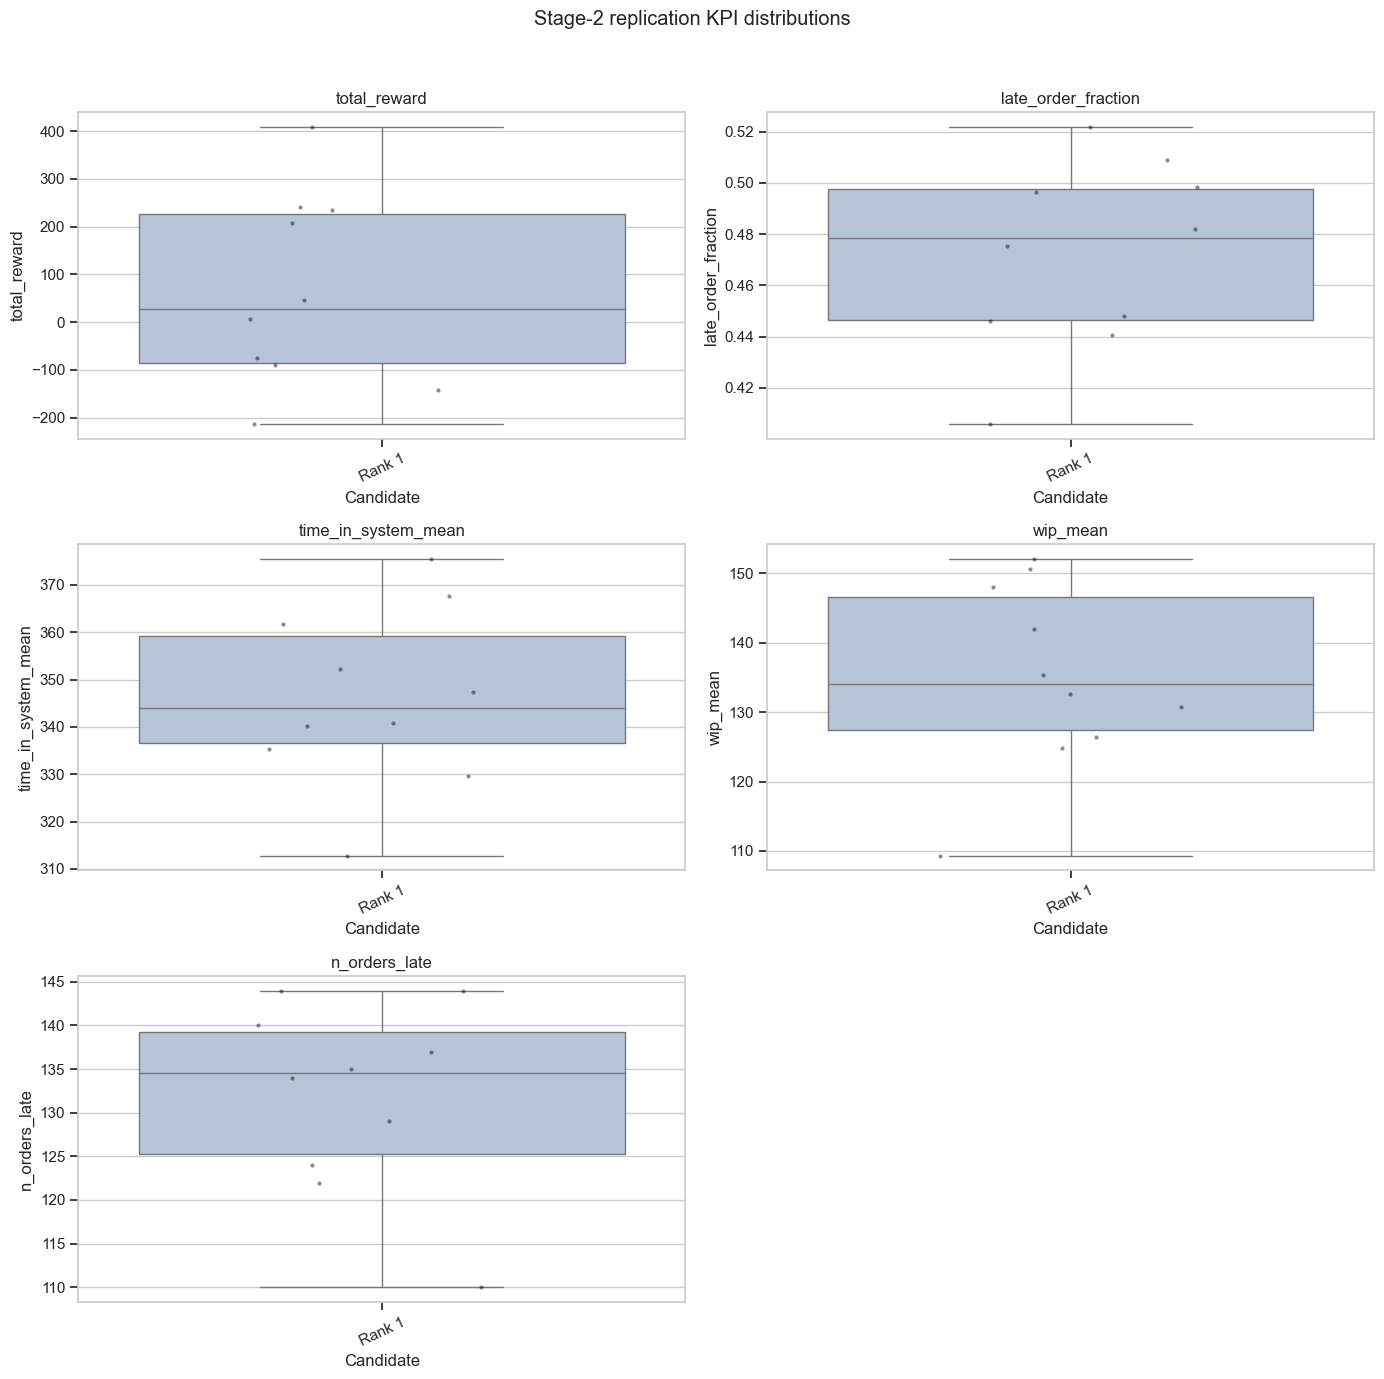

In [10]:
metrics = [m for m in ["total_reward", "late_order_fraction", "time_in_system_mean", "wip_mean", "n_orders_late"] if m in stage2_evaluations.columns]
if stage2_evaluations.empty or not metrics:
    fig, ax = plt.subplots(figsize=(8,4)); empty_plot_message(ax, "No Stage-2 replication KPI distributions available."); plt.show()
else:
    n_cols=2; n_rows=math.ceil(len(metrics)/n_cols); fig, axes = plt.subplots(n_rows,n_cols,figsize=(7*n_cols,4.5*n_rows), squeeze=False)
    order = sorted(stage2_evaluations["candidate_label"].dropna().unique())
    for ax, metric in zip(axes.ravel(), metrics):
        sns.boxplot(data=stage2_evaluations, x="candidate_label", y=metric, order=order, ax=ax, color="lightsteelblue", showfliers=False)
        sns.stripplot(data=stage2_evaluations, x="candidate_label", y=metric, order=order, ax=ax, color="black", alpha=0.45, size=3, jitter=0.22)
        ax.set_title(metric); ax.set_xlabel("Candidate"); ax.tick_params(axis="x", rotation=25)
    for ax in axes.ravel()[len(metrics):]: ax.set_axis_off()
    fig.suptitle("Stage-2 replication KPI distributions", y=1.02); plt.tight_layout(); plt.show()